# 05 · Visualização

**Teste prático de Analytics Engineer (estágio) · Klubi**

Tarefa 5 do desafio: no mínimo três gráficos, sendo um mapa de calor de correlação, uma análise detalhada da variável de maior impacto e uma comparação por faixas.

Os notebooks 01 a 04 calcularam. Este **comunica**: cada gráfico aqui foi montado para ser lido por alguém que não acompanhou a análise, e responde a uma pergunta sozinho, sem depender do texto ao redor.

### Índice

1. Setup
2. Base preparada
3. Mapa de calor: o que se relaciona com o quê
4. A variável de maior impacto, em detalhe
5. Comparação por faixas
6. O dashboard

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

CSV = Path("../data/raw/habitos_e_desempenho_estudantil.csv")
if not CSV.exists():
    CSV = Path("data/raw/habitos_e_desempenho_estudantil.csv")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

print(f"pandas {pd.__version__}  ·  numpy {np.__version__}")

pandas 3.0.6  ·  numpy 2.5.3


In [2]:
COR = {
    "serie_1":    "#2a78d6",
    "serie_2":    "#eb6834",
    "critico":    "#d03b3b",
    "superficie": "#fcfcfb",
    "tinta":      "#0b0b0b",
    "tinta_2":    "#52514e",
    "suave":      "#898781",
    "grade":      "#e1e0d9",
    "eixo":       "#c3c2b7",
    "neutro":     "#f0efec",
}

# Rampa ordinal azul, do claro ao escuro. Serve para faixas, que têm ordem
# natural: o degrau mais claro já precisa se destacar do fundo, por isso a
# rampa não começa no tom mais pálido.
RAMPA = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]

# Escala divergente para correlação: laranja no negativo, cinza neutro no zero
# (precisa ler como "nada"), azul no positivo.
DIVERGENTE = LinearSegmentedColormap.from_list(
    "corr", ["#b4441a", COR["serie_2"], "#f5c4ad", COR["neutro"],
             "#9ec5f4", COR["serie_1"], "#184f95"],
)

plt.rcParams.update({
    "figure.facecolor":   COR["superficie"],
    "axes.facecolor":     COR["superficie"],
    "savefig.facecolor":  COR["superficie"],
    "figure.dpi":         110,
    "font.family":        "sans-serif",
    "font.size":          9.5,
    "text.color":         COR["tinta"],
    "axes.titlesize":     10.5,
    "axes.titleweight":   "bold",
    "axes.titlecolor":    COR["tinta"],
    "axes.titlelocation": "left",
    "axes.titlepad":      9,
    "axes.labelsize":     9,
    "axes.labelcolor":    COR["tinta_2"],
    "axes.edgecolor":     COR["eixo"],
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "axes.axisbelow":     True,
    "grid.color":         COR["grade"],
    "grid.linewidth":     0.8,
    "grid.linestyle":     "-",
    "xtick.color":        COR["suave"],
    "ytick.color":        COR["suave"],
    "xtick.labelsize":    8.5,
    "ytick.labelsize":    8.5,
    "xtick.bottom":       False,
    "ytick.left":         False,
    "legend.frameon":     False,
    "legend.fontsize":    9,
})


def so_grade(ax, eixo="y"):
    "Deixa grade em um eixo só. O dado é a única coisa que pode ser forte."
    ax.grid(axis=eixo, visible=True)
    ax.grid(axis="x" if eixo == "y" else "y", visible=False)
    return ax

## 2. Base preparada

In [3]:
INTEIRAS = ["age", "exercise_frequency", "mental_health_rating"]
DECIMAIS = ["study_hours_per_day", "social_media_hours", "netflix_hours",
            "attendance_percentage", "sleep_hours", "exam_score"]
ORDINAIS = {
    "diet_quality":             ["Poor", "Fair", "Good"],
    "internet_quality":         ["Poor", "Average", "Good"],
    "parental_education_level": ["None", "High School", "Bachelor", "Master"],
}
FAIXAS = {
    "faixa_estudo": ("study_hours_per_day", [0, 2, 3, 4, 5, np.inf],
                     ["menos de 2h", "2h a 3h", "3h a 4h", "4h a 5h", "5h ou mais"]),
    "faixa_redes":  ("social_media_hours", [0, 1, 2, 3, 4, np.inf],
                     ["menos de 1h", "1h a 2h", "2h a 3h", "3h a 4h", "4h ou mais"]),
    "faixa_sono":   ("sleep_hours", [0, 6, 7, 8, np.inf],
                     ["menos de 6h", "6h a 7h", "7h a 8h", "8h ou mais"]),
}


def preparar_dados(csv=CSV):
    "Lê o CSV cru e devolve a base tratada. Idêntica à do notebook 02."
    base = pd.read_csv(csv, dtype=str, na_filter=False)
    base[INTEIRAS] = base[INTEIRAS].astype(int)
    base[DECIMAIS] = base[DECIMAIS].astype(float)

    for coluna, ordem in ORDINAIS.items():
        base[coluna] = pd.Categorical(base[coluna], categories=ordem, ordered=True)
        base[f"{coluna}_cod"] = base[coluna].cat.codes

    base["tempo_tela_total"] = base["social_media_hours"] + base["netflix_hours"]

    for nova, (origem, cortes, rotulos) in FAIXAS.items():
        base[nova] = pd.cut(base[origem], bins=cortes, labels=rotulos,
                            right=False, ordered=True)
    return base


df = preparar_dados()
ALVO = "exam_score"
alvo = df[ALVO]
print(f"{df.shape[0]} linhas × {df.shape[1]} colunas  ·  NaN: {int(df.isna().sum().sum())}")

1000 linhas × 23 colunas  ·  NaN: 0


## 3. Mapa de calor: o que se relaciona com o quê

O notebook 03 já trouxe a matriz completa, com as catorze variáveis. Esta versão é a de apresentação: fora as seis que o intervalo de confiança mostrou serem indistinguíveis de zero, e com as células grandes o bastante para ler o número sem apertar o olho.

O corte não é maquiagem. Manter na figura seis variáveis que não explicam nada obriga quem lê a descobrir sozinho quais ignorar.

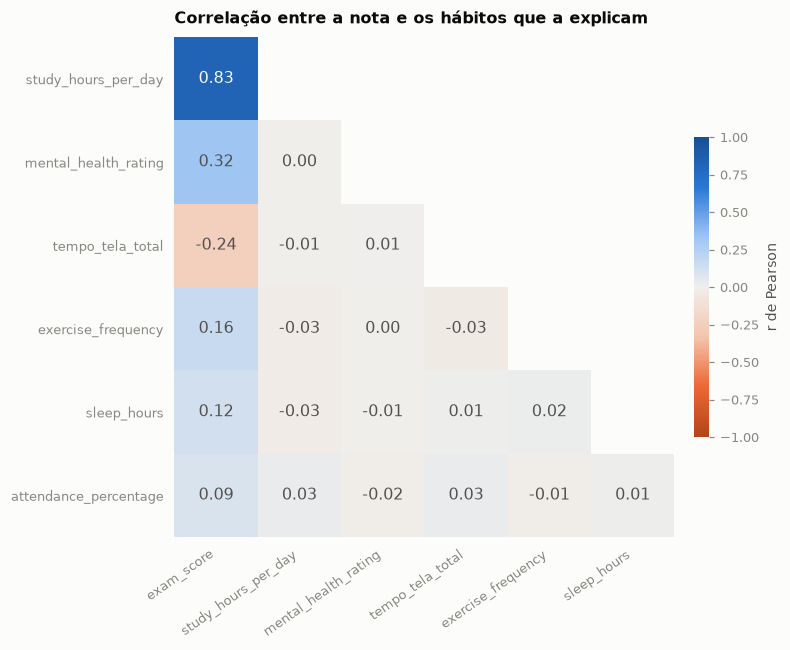

In [4]:
# As seis variáveis com efeito detectável sobre a nota, segundo o notebook 03,
# mais o próprio alvo.
RELEVANTES = [ALVO, "study_hours_per_day", "mental_health_rating",
              "tempo_tela_total", "exercise_frequency", "sleep_hours",
              "attendance_percentage"]

matriz = df[RELEVANTES].corr()

fig, ax = plt.subplots(figsize=(7.6, 6))

# Triângulo inferior estrito, sem a primeira linha nem a última coluna: a
# matriz é simétrica e a diagonal vale sempre 1,00.
recorte = matriz.iloc[1:, :-1]
visivel = recorte.mask(np.triu(np.ones(recorte.shape, dtype=bool), k=1))
im = ax.imshow(visivel, cmap=DIVERGENTE, vmin=-1, vmax=1)

for i in range(recorte.shape[0]):
    for j in range(i + 1):
        v = recorte.iloc[i, j]
        texto = f"{v:.2f}".replace("-0.00", "0.00")
        # Texto claro sobre célula escura, tinta sobre célula clara.
        ax.text(j, i, texto, ha="center", va="center", fontsize=10.5,
                color=COR["superficie"] if abs(v) > 0.55 else COR["tinta_2"])

ax.set_xticks(range(recorte.shape[1]), recorte.columns, rotation=35, ha="right")
ax.set_yticks(range(recorte.shape[0]), recorte.index)
ax.set_title("Correlação entre a nota e os hábitos que a explicam")
ax.grid(visible=False)
for lado in ax.spines.values():
    lado.set_visible(False)

barra = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.03)
barra.set_label("r de Pearson", color=COR["tinta_2"], fontsize=9)
barra.outline.set_visible(False)

plt.tight_layout()
plt.show()

A primeira coluna é a resposta: `study_hours_per_day` com 0,83, `mental_health_rating` com 0,32, `tempo_tela_total` com -0,24, e o resto encostando em zero.

O resto da figura é quase todo cinza, e isso é informação, não vazio. **Os hábitos não se relacionam entre si**: quem estuda mais não dorme menos, quem usa mais tela não se exercita menos. Em estudantes reais esses comportamentos vêm em pacote, e a independência perfeita aqui é a assinatura mais clara de que a base é sintética.

## 4. A variável de maior impacto, em detalhe

`study_hours_per_day` sozinha acompanha 68% da variação da nota. Três painéis, cada um respondendo a uma pergunta diferente sobre ela.

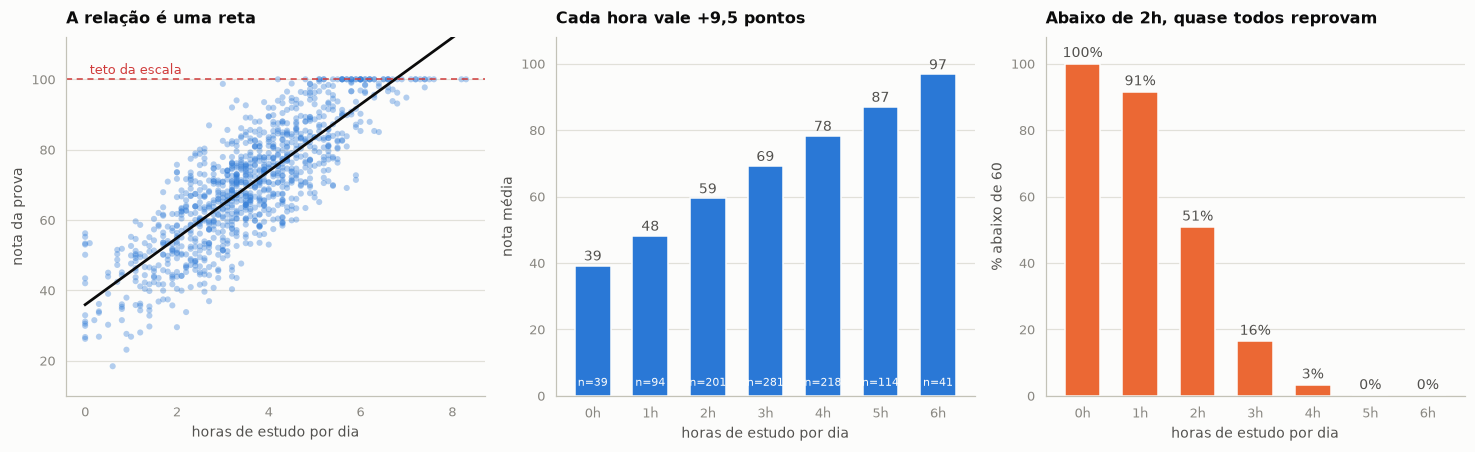

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13.5, 4.2))

x, y = df["study_hours_per_day"], alvo

# ── Painel 1: a relação é reta? ──
ax1.scatter(x, y, s=16, color=COR["serie_1"], alpha=0.35,
            edgecolor="none")
inclinacao, intercepto = np.polyfit(x, y, 1)
grade_x = np.linspace(x.min(), x.max(), 100)
ax1.plot(grade_x, inclinacao * grade_x + intercepto, color=COR["tinta"], linewidth=1.8)
ax1.axhline(100, color=COR["critico"], linewidth=1, linestyle=(0, (4, 3)))
ax1.text(0.1, 101.5, "teto da escala", color=COR["critico"], fontsize=8.5)
ax1.set_title("A relação é uma reta")
ax1.set_xlabel("horas de estudo por dia")
ax1.set_ylabel("nota da prova")
ax1.set_ylim(10, 112)
so_grade(ax1)

# ── Painel 2: quanto vale cada hora? ──
# Média por hora cheia: tira o ruído do ponto a ponto e deixa a inclinação
# visível como degrau, que é como a informação vai ser usada numa conversa.
faixa_hora = pd.cut(x, bins=np.arange(0, 10), right=False)
por_hora = y.groupby(faixa_hora, observed=True).agg(["size", "mean"])
por_hora = por_hora[por_hora["size"] >= 15]   # descarta faixa com gente demais de menos

centros = np.arange(len(por_hora))
ax2.bar(centros, por_hora["mean"], width=0.62, color=COR["serie_1"],
        edgecolor=COR["superficie"], linewidth=1)
for i, (m, n) in enumerate(zip(por_hora["mean"], por_hora["size"])):
    ax2.text(i, m + 1.5, f"{m:.0f}", ha="center", fontsize=9, color=COR["tinta_2"])
    ax2.text(i, 3, f"n={n}", ha="center", fontsize=7.5, color=COR["superficie"])

ax2.set_xticks(centros, [f"{int(iv.left)}h" for iv in por_hora.index])
ax2.set_title(f"Cada hora vale +{inclinacao:.1f} pontos".replace(".", ","))
ax2.set_xlabel("horas de estudo por dia")
ax2.set_ylabel("nota média")
ax2.set_ylim(0, 108)
so_grade(ax2)

# ── Painel 3: quem estuda pouco reprova? ──
CORTE = 60
reprova = y.groupby(faixa_hora, observed=True).apply(lambda s: (s < CORTE).mean())
reprova = reprova[por_hora.index]

ax3.bar(centros, 100 * reprova, width=0.62, color=COR["serie_2"],
        edgecolor=COR["superficie"], linewidth=1)
for i, v in enumerate(100 * reprova):
    ax3.text(i, v + 2, f"{v:.0f}%", ha="center", fontsize=9, color=COR["tinta_2"])

ax3.set_xticks(centros, [f"{int(iv.left)}h" for iv in por_hora.index])
ax3.set_title("Abaixo de 2h, quase todos reprovam")
ax3.set_xlabel("horas de estudo por dia")
ax3.set_ylabel("% abaixo de 60")
ax3.set_ylim(0, 108)
so_grade(ax3)

plt.tight_layout()
plt.show()

**Painel 1.** A nuvem acompanha a reta de ponta a ponta, sem curva, sem funil, sem saturação. É o que autoriza usar regressão linear e falar em "pontos por hora" como se fosse uma taxa constante, porque é.

A única anomalia está encostada na linha tracejada: os alunos comprimidos no teto de 100, que o notebook 01 diagnosticou e o notebook 04 reencontrou.

**Painel 2.** A mesma informação em degraus, que é como ela vira conversa: quem estuda 1h tira 48 em média, quem estuda 5h tira 87. Cerca de **+9,6 pontos por hora**, de forma estável ao longo de toda a escala.

**Painel 3.** É o painel que um coordenador olha primeiro. Na faixa de 0h a 1h de estudo, **100% e 91% reprovam**. Em 3h já são 16%, em 4h são 3%, e de 5h em diante ninguém. A transição é abrupta e acontece entre 2h e 4h, que é exatamente onde vale concentrar esforço: tirar um aluno de 2h para 3h derruba o risco de reprovação de 51% para 16%.

## 5. Comparação por faixas

As faixas criadas no notebook 02 servem justamente a isto: comparar grupos que uma pessoa consegue nomear. Boxplot mostra mediana, dispersão e sobreposição de uma vez, o que uma média sozinha esconde.

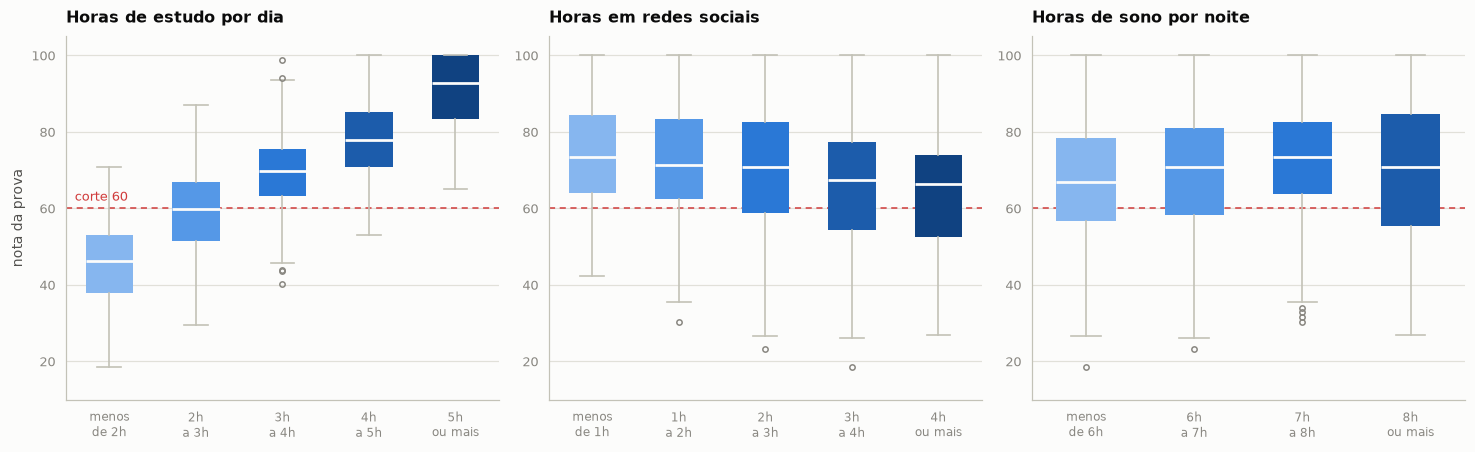

In [6]:
fig, eixos = plt.subplots(1, 3, figsize=(13.5, 4.2))

PAINEIS = [
    ("faixa_estudo", "Horas de estudo por dia", True),
    ("faixa_redes",  "Horas em redes sociais", False),
    ("faixa_sono",   "Horas de sono por noite", False),
]

for ax, (coluna, titulo, destacar) in zip(eixos, PAINEIS):
    categorias = list(df[coluna].cat.categories)
    dados = [alvo[df[coluna] == c].to_numpy() for c in categorias]

    # Rampa ordinal: a faixa tem ordem, então a cor também tem. Escurece com a
    # posição na escala, nunca com o valor da nota.
    passo = max(1, len(RAMPA) // len(categorias))
    cores = [RAMPA[min(i * passo, len(RAMPA) - 1)] for i in range(len(categorias))]

    caixas = ax.boxplot(dados, patch_artist=True, widths=0.55,
                        medianprops=dict(color=COR["superficie"], linewidth=1.8),
                        whiskerprops=dict(color=COR["eixo"], linewidth=1.1),
                        capprops=dict(color=COR["eixo"], linewidth=1.1),
                        flierprops=dict(markeredgecolor=COR["suave"], markersize=3.5))
    for caixa, cor in zip(caixas["boxes"], cores):
        caixa.set(facecolor=cor, edgecolor="none")

    ax.axhline(60, color=COR["critico"], linewidth=1, linestyle=(0, (4, 3)), zorder=1)

    ax.set_xticks(range(1, len(categorias) + 1),
                  [c.replace(" ", "\n", 1) for c in categorias], fontsize=8)
    ax.set_title(titulo)
    ax.set_ylim(10, 105)
    if ax is eixos[0]:
        ax.set_ylabel("nota da prova")
        ax.text(0.6, 62, "corte 60", color=COR["critico"], fontsize=8.5)
    so_grade(ax)

plt.tight_layout()
plt.show()

In [7]:
# A mesma comparação em número, para quem precisar citar.
resumo = []
for coluna, titulo, _ in [("faixa_estudo", "", 0), ("faixa_redes", "", 0), ("faixa_sono", "", 0)]:
    g = alvo.groupby(df[coluna], observed=True)
    for faixa, serie in g:
        resumo.append({
            "variável": coluna.replace("faixa_", ""),
            "faixa": faixa,
            "alunos": len(serie),
            "mediana": serie.median(),
            "abaixo_de_60": f"{100 * (serie < 60).mean():.0f}%",
        })

pd.DataFrame(resumo).set_index(["variável", "faixa"])

alunos  mediana abaixo_de_60
variável faixa                                    
estudo   menos de 2h     133    46.30          94%
         2h a 3h         201    59.80          51%
         3h a 4h         281    69.70          16%
         4h a 5h         218    77.85           3%
         5h ou mais      167    92.90           0%
redes    menos de 1h      98    73.55          22%
         1h a 2h         227    71.40          19%
         2h a 3h         311    70.80          27%
         3h a 4h         251    67.40          34%
         4h ou mais      113    66.40          39%
sono     menos de 6h     343    66.90          33%
         6h a 7h         312    70.75          28%
         7h a 8h         226    73.50          19%
         8h ou mais      119    70.80          31%

Os três painéis têm escalas iguais de propósito, para que a comparação entre eles seja honesta.

**Estudo separa, e separa muito.** As caixas sobem em degraus limpos e quase não se sobrepõem: quem estuda menos de 2h tem mediana abaixo da linha de corte, quem estuda 5h ou mais tem a caixa inteira acima de 80. É a única das três em que as faixas realmente descrevem grupos diferentes.

**Redes sociais separa pouco.** Há uma inclinação para baixo, coerente com o r de -0,17, mas as caixas se sobrepõem quase inteiras. Existe efeito, e ele é pequeno perto do anterior.

**Sono separa menos ainda, e não do jeito que se espera.** Não há faixa ótima: o grupo que dorme menos de 6h fica um pouco abaixo, e daí para cima as caixas são praticamente iguais. Dormir 9h não é melhor que dormir 7h nesta base. O sinal do sono é um piso ruim, não um ponto ideal, exatamente como o notebook 02 já tinha medido quando descartou a variável `sono_insuficiente`.

## 6. O dashboard

O enunciado trata dashboard como diferencial. Ele existe, e não como peça separada: os gráficos desta tarefa entraram no mesmo app do notebook 04, em [`app.py`](../app.py), na aba **Panorama da turma**.

![Panorama da turma](../assets/img/app-panorama.png)

A diferença entre o notebook e o app é o que cada um permite. Aqui os gráficos estão fixos, escolhidos para contar a história que a análise encontrou. No app, quem usa escolhe qual hábito inspecionar e qual recorte comparar, o que serve a perguntas que eu não anteciparia.

### Por que os dois painéis dividem o eixo

A primeira versão do app punha um gráfico de dispersão ao lado das barras de risco. Não funcionava, por dois motivos que só aparecem quando se troca o hábito no seletor.

**Em variável discreta a dispersão não mostra nada.** Exercício vai de 0 a 6 e saúde mental de 1 a 10, então mil pontos viram sete ou dez listras verticais. Não dá para ver densidade, não dá para ver relação, e a reta de tendência flutua por cima sem se apoiar em nada.

**E os dois painéis tinham eixos x diferentes**, um contínuo em horas e outro em faixas. O olho não consegue ligar um ao outro, e o leitor precisa refazer a tradução mentalmente a cada leitura.

A versão atual empilha os dois no **mesmo eixo de faixas**: em cima a distribuição da nota em cada faixa, embaixo quanto daquela faixa fica abaixo do corte. **Cada faixa mantém a mesma cor nos dois painéis**, que é o que amarra a leitura. Com isso a mesma figura funciona para variável contínua e discreta, e a comparação entre um hábito forte e um fraco fica imediata: horas de estudo desenha uma escada e o risco desaba de 94% para zero, enquanto exercício mostra caixas sobrepostas e barras quase planas.

### Próximo passo

**Notebook 06, síntese de insights**: quais hábitos mais afetam as notas, que recomendações práticas surgem daí, e se existe diferença entre grupos.